# 03 · Master Panel and Turnout Analysis (Component A)

Notebook 3 of 6 · **Eastern Cape Municipal Electoral Dynamics**

**Question.** *How are municipal demographic structure and political competition associated with voter turnout across Eastern Cape municipalities?*

| | |
|---|---|
| **Inputs** | Phase 1 election panel and party shares; Phase 2 demographics |
| **Outputs** | `data/processed/panels/phase3/*.csv` (incl. the master panel), figures in `reports/figures/phase3/` |
| **Code** | `src/features/panel.py`, `src/analysis/associations.py` |

**At a glance**
- Turnout was stable at 56–58% from 2000 to 2016, then fell in **every one of the 33 municipalities** in 2021 (mean fall about 8 points).
- Two different questions are answered separately. **Across elections**, turnout fell while party numbers and service levels rose. **Within an election**, the relationships between municipalities often point the other way: pooled correlations for ENP, matric, electricity and formal housing have the **opposite sign** to the within-election ones, because pooling is dominated by the 2021 shift (Simpson's paradox).
- Within elections, the pattern is consistent: municipalities with **younger populations** have lower turnout, those with **better services and more matric holders** have higher turnout, and **closer contests** go with higher turnout.
- The election year alone explains about half of all turnout variation; municipal characteristics add about 12 percentage points of R². They overlap so strongly that their separate effects cannot be distinguished with 33 municipalities.
- A municipality's turnout **relative to the province** is highly persistent since 2011 (r ≈ 0.8), which Notebook 04 turns into a forecasting model.

All results are municipality-level **associations**, not causal effects and not statements about how individuals behave.

In [1]:
# Setup: locate the repository root so this notebook runs from any working folder,
# then import the shared project code in src/ (the single source of truth for logic).
import sys, warnings
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import config as C
from src.visualization.style import apply_style, subtitle, save, choropleth, map_colorbar, source_note, SEQ_CMAP, DIV_CMAP

apply_style()
C.ensure_dirs()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.precision", 2)
print("Repository root:", ROOT.name)

Repository root: Dirisa_TeamQualification


## 1. Build the master panel

One row per municipality × election, joining turnout and competition (Phase 1), party shares and swings (Phase 1), descriptive demographics and as-known demographics (Phase 2), and the turnout decomposition used later:

$$\text{Turnout}_{m,t} = \underbrace{\text{Level}_t}_{\text{provincial mean}} + \underbrace{\text{Relative}_{m,t}}_{\text{municipality's position}}$$

In [2]:
from src.features.panel import build_master_panel, provincial_summary
p1, p2 = C.DIRS["phase1"], C.DIRS["phase2"]
elections = pd.read_csv(p1 / "municipality_election_panel_2000_2021.csv")
party_wide = pd.read_csv(p1 / "party_shares_selected_wide_2000_2021.csv")
demo_desc = pd.read_csv(p2 / "demographics_descriptive_2000_2021.csv")
demo_known = pd.read_csv(p2 / "demographics_as_known_2000_2026.csv")

master = build_master_panel(elections, party_wide, demo_desc, demo_known)
print("Master panel:", master.shape)
display(master[["MuniCode", "Municipality", "District", "Year", "Turnout_%", "ProvincialLevel_%",
                "RelativeTurnout_pts", "ENP", "Margin_pts", "ANC", "DA", "U15", "Water"]].head(8))

Master panel: (164, 71)


,MuniCode,Municipality,District,Year,Turnout_%,ProvincialLevel_%,RelativeTurnout_pts,ENP,Margin_pts,ANC,DA,U15,Water
0,BUF,Buffalo City,Buffalo City (metro),2000,58.00,56.3,1.70,1.47,68.02,81.27,13.25,NaN,NaN
1,EC101,Dr Beyers Naude,Sarah Baartman,2000,61.70,56.3,5.39,2.36,22.21,55.46,33.25,NaN,NaN
2,EC102,Blue Crane Route,Sarah Baartman,2000,54.71,56.3,-1.60,1.76,43.62,70.34,26.72,NaN,NaN
3,EC104,Makana,Sarah Baartman,2000,57.66,56.3,1.36,1.44,67.78,82.02,14.24,NaN,NaN
4,EC105,Ndlambe,Sarah Baartman,2000,63.26,56.3,6.95,1.62,54.62,75.56,20.94,NaN,NaN
5,EC106,Sundays River Valley,Sarah Baartman,2000,60.33,56.3,4.03,1.37,67.62,83.81,16.19,NaN,NaN
6,EC108,Kouga,Sarah Baartman,2000,61.31,56.3,5.00,2.19,3.27,49.38,46.11,NaN,NaN
7,EC109,Kou-Kamma,Sarah Baartman,2000,57.94,56.3,1.63,1.91,31.70,64.49,32.79,NaN,NaN


In [3]:
demo_cols = ["Pop", "U15", "O65", "Med", "NoSch", "Matric", "Higher", "Formal", "Water", "Elec"]
qc = pd.DataFrame([
    ("Rows", len(master), 164),
    ("Duplicate keys", int(master.duplicated(["MuniCode", "Year"]).sum()), 0),
    ("Rows missing party shares", int(master[C.PARTIES].isna().any(axis=1).sum()), 0),
    ("2011+ rows with complete descriptive demographics", int(master.loc[master["Year"] >= 2011, demo_cols].notna().all(axis=1).sum()), 99),
    ("Pre-2011 rows with demographics (should be none)", int(master.loc[master["Year"] < 2011, demo_cols].notna().any(axis=1).sum()), 0),
    ("Relative turnout sums to ~0 within each year", int((master.groupby("Year")["RelativeTurnout_pts"].sum().abs() > 1e-9).sum()), 0),
], columns=["Check", "Actual", "Expected"])
qc["Pass"] = qc["Actual"] == qc["Expected"]
display(qc); assert qc["Pass"].all(), "Phase 3 QC failed"

,Check,Actual,Expected,Pass
0,Rows,164,164,True
1,Duplicate keys,0,0,True
2,Rows missing party shares,0,0,True
3,2011+ rows with complete descriptive demographics,99,99,True
4,Pre-2011 rows with demographics (should be none),0,0,True
5,Relative turnout sums to ~0 within each year,0,0,True


## 2. Turnout over five elections

,Year,Municipalities,MeanTurnout,WeightedTurnout,SDTurnout,MinTurnout,MaxTurnout,MeanParties,MeanENP
0,2000,32,56.30,56.16,5.15,43.05,66.83,3.34,1.62
1,2006,33,57.19,56.33,3.45,49.66,63.71,4.88,1.46
2,2011,33,58.03,57.86,4.71,46.68,68.27,5.88,1.58
3,2016,33,56.23,56.17,4.35,45.11,66.11,7.06,1.76
4,2021,33,48.03,46.36,3.96,39.42,57.01,10.15,2.00


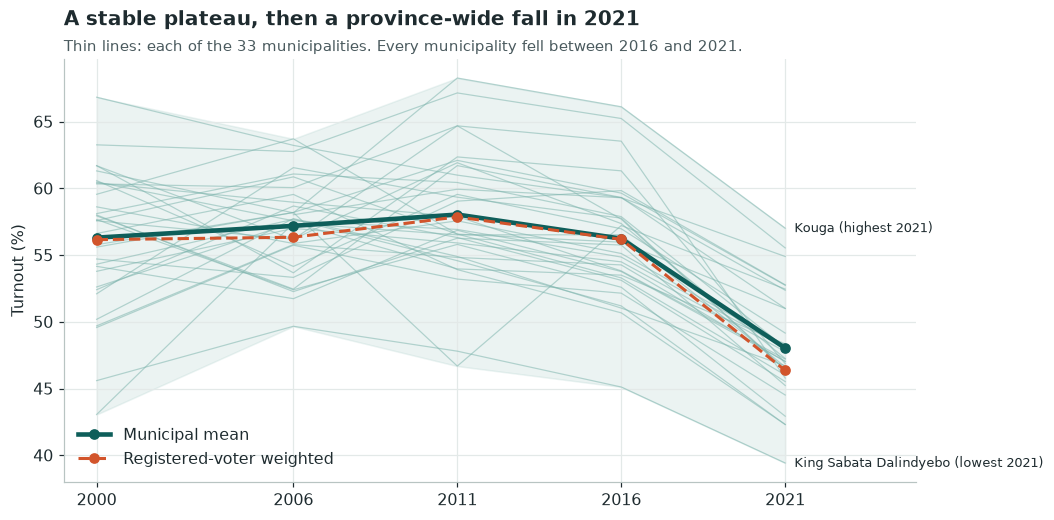

In [4]:
summary = provincial_summary(master)
display(summary[["Year", "Municipalities", "MeanTurnout", "WeightedTurnout", "SDTurnout", "MinTurnout", "MaxTurnout", "MeanParties", "MeanENP"]].round(2))

fig, ax = plt.subplots(figsize=(10, 5))
for code, g in master.groupby("MuniCode"):
    ax.plot(g["Year"], g["Turnout_%"], color=C.TEAL_LIGHT, lw=.8, alpha=.55)
ax.fill_between(summary["Year"], summary["MinTurnout"], summary["MaxTurnout"], color=C.TEAL_LIGHT, alpha=.15)
ax.plot(summary["Year"], summary["MeanTurnout"], color=C.TEAL, lw=3, marker="o", label="Municipal mean")
ax.plot(summary["Year"], summary["WeightedTurnout"], color=C.ALOE, lw=2, ls="--", marker="o", label="Registered-voter weighted")
for name, code in [("Kouga (highest 2021)", "EC108"), ("King Sabata Dalindyebo (lowest 2021)", "EC157")]:
    g = master[master["MuniCode"] == code]
    ax.annotate(name, (2021, g["Turnout_%"].iloc[-1]), xytext=(6, 0), textcoords="offset points", fontsize=8.5, va="center")
ax.set_xticks(summary["Year"]); ax.set_xlim(1999, 2025); ax.set_ylabel("Turnout (%)"); ax.legend(loc="lower left")
ax.set_title("A stable plateau, then a province-wide fall in 2021", pad=22)
subtitle(ax, "Thin lines: each of the 33 municipalities. Every municipality fell between 2016 and 2021.")
save(fig, "turnout_trend", "phase3"); plt.show()

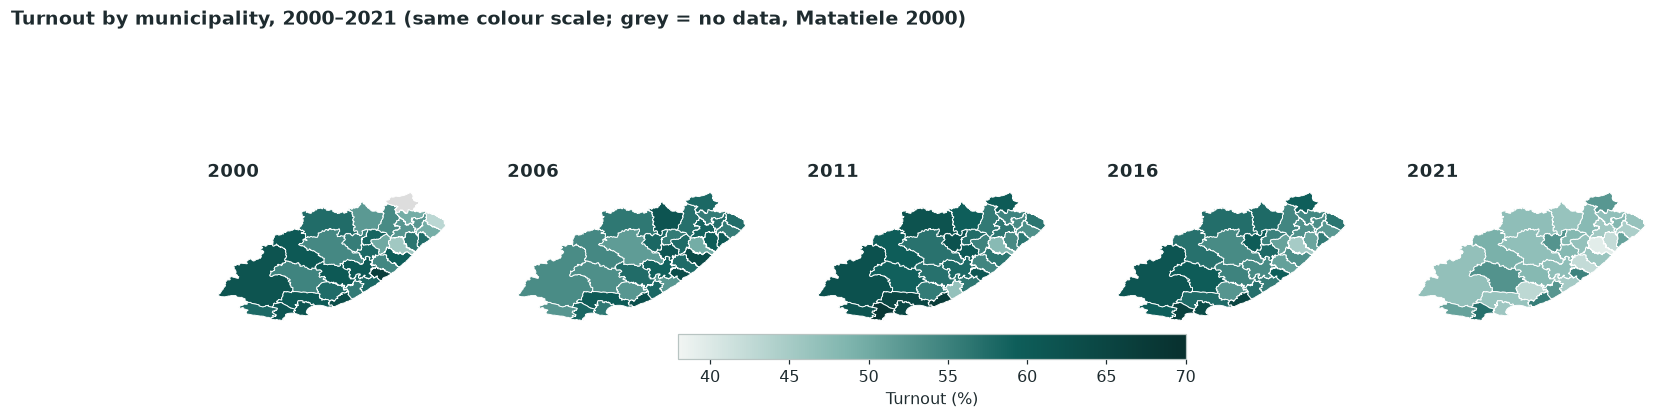

In [5]:
from src.data.geography import load_geojson
geo = load_geojson()
fig, axes = plt.subplots(1, 5, figsize=(17, 3.9))
for ax, y in zip(axes, C.ELECTION_YEARS):
    d = master[master["Year"] == y]
    sm = choropleth(ax, geo, dict(zip(d["MuniCode"], d["Turnout_%"])), vmin=38, vmax=70)
    ax.set_title(str(y), fontsize=12)
fig.colorbar(sm, ax=axes, orientation="horizontal", shrink=.35, pad=.02, label="Turnout (%)")
fig.suptitle("Turnout by municipality, 2000–2021 (same colour scale; grey = no data, Matatiele 2000)",
             x=.02, ha="left", fontsize=12.5, fontweight="bold")
save(fig, "turnout_maps_2000_2021", "phase3"); plt.show()

Municipalities whose turnout fell 2016 -> 2021: 33 of 33
Mean change: -8.2 | range: -17.7 to -4.3


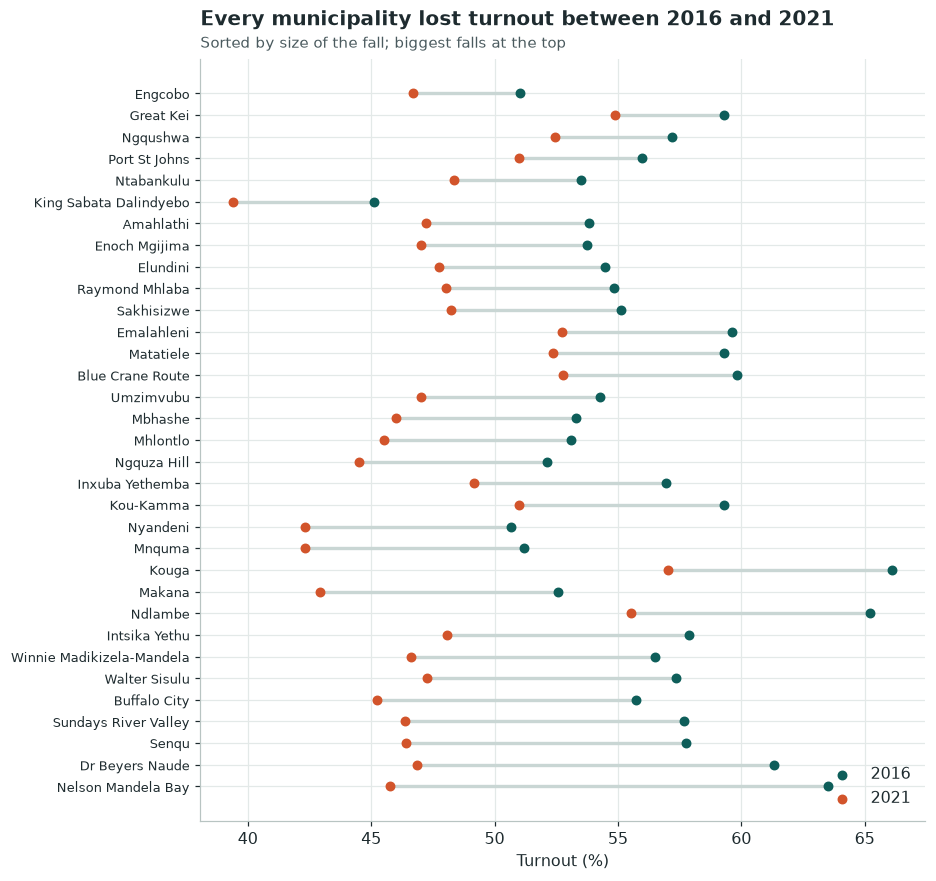

In [6]:
chg = master.pivot(index="MuniCode", columns="Year", values="Turnout_%")[[2011, 2016, 2021]].copy()
chg["Change_2016_2021_pts"] = chg[2021] - chg[2016]
chg["Change_2011_2021_pts"] = chg[2021] - chg[2011]
chg["Municipality"] = chg.index.map(C.muni_name)
chg = chg.sort_values("Change_2016_2021_pts").reset_index()
print("Municipalities whose turnout fell 2016 -> 2021:", int((chg["Change_2016_2021_pts"] < 0).sum()), "of", len(chg))
print("Mean change:", round(chg["Change_2016_2021_pts"].mean(), 2), "| range:",
      round(chg["Change_2016_2021_pts"].min(), 1), "to", round(chg["Change_2016_2021_pts"].max(), 1))

fig, ax = plt.subplots(figsize=(8.5, 9))
y = np.arange(len(chg))
ax.hlines(y, chg[2021], chg[2016], color="#C9D6D4", lw=2.2)
ax.scatter(chg[2016], y, color=C.TEAL, s=30, label="2016", zorder=3)
ax.scatter(chg[2021], y, color=C.ALOE, s=30, label="2021", zorder=3)
ax.set_yticks(y); ax.set_yticklabels(chg["Municipality"], fontsize=8.5)
ax.set_xlabel("Turnout (%)"); ax.legend(loc="lower right")
ax.set_title("Every municipality lost turnout between 2016 and 2021", pad=22)
subtitle(ax, "Sorted by size of the fall; biggest falls at the top")
save(fig, "turnout_change_2016_2021", "phase3"); plt.show()

**Reading these charts.** The 2021 fall was universal, not concentrated in particular places: the smallest fall was still several points. That is the signature of a **province-wide (indeed national) shock**. The 2021 election was held on 1 November 2021, during the COVID-19 pandemic, and national turnout also fell sharply. Whatever its causes, a shock that hits every municipality cannot be explained by differences *between* municipalities, which is why the rest of this notebook analyses differences **within** each election.

## 3. Two questions, two analyses

1. **Across elections:** how did participation, competition and socioeconomic conditions change over time?
2. **Within an election:** under the same election-year environment, why did municipalities differ from one another?

The first is answered by provincial trends; the second by correlations computed inside each election (or with election-year effects removed). Pooling 2011, 2016 and 2021 into one correlation mixes the two, and between 2016 and 2021 turnout fell everywhere *while* party numbers and (interpolated) service levels rose everywhere, so the shared trend can dominate.

### 3a. Across elections: what changed over time

In [7]:
across = (master[master["Year"] >= 2011].groupby("Year")
          [["Turnout_%", "NumberOfParties", "ENP", "Margin_pts", "U15", "Matric", "Water", "Elec", "Formal"]].mean())
display(across.round(2))
print("Every column moves between elections: turnout down, competition up, services and education up (2016/2021 interpolated).")

,Turnout_%,NumberOfParties,ENP,Margin_pts,U15,Matric,Water,Elec,Formal
Year,,,,,,,,,
2011,58.03,5.88,1.58,60.52,33.42,16.15,45.15,73.63,61.75
2016,56.23,7.06,1.76,54.07,31.65,19.72,52.97,83.04,71.07
2021,48.03,10.15,2.00,51.13,29.89,23.29,60.78,92.45,80.40


Every column moves between elections: turnout down, competition up, services and education up (2016/2021 interpolated).


### 3b. Within an election versus pooled across elections

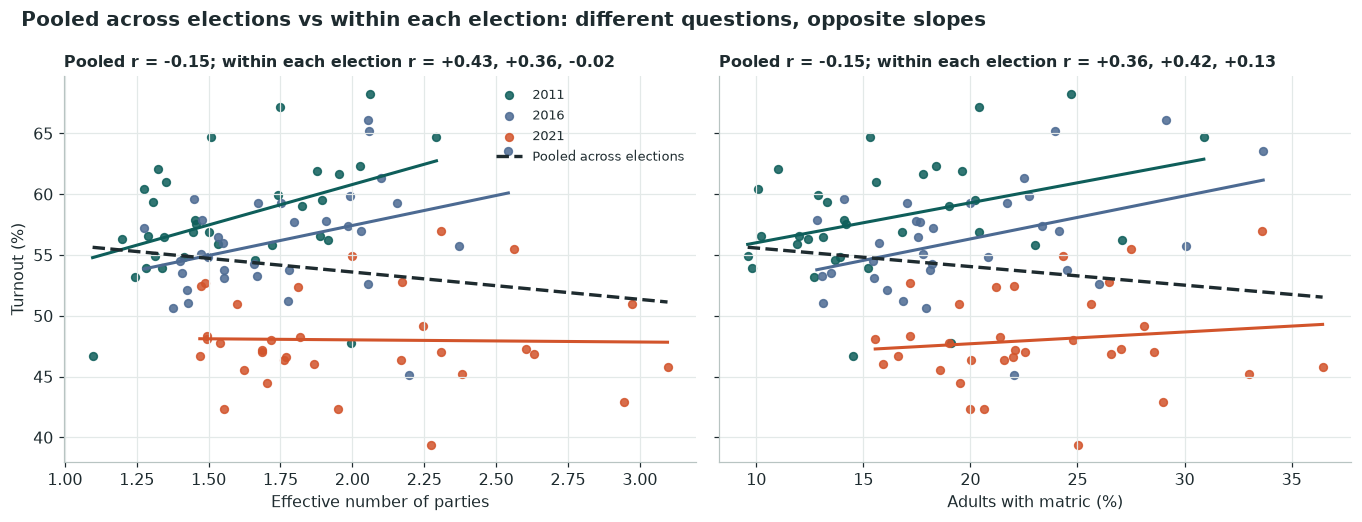

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
d = master[master["Year"] >= 2011]
cols = {2011: C.TEAL, 2016: "#4C6A92", 2021: C.ALOE}
for ax, var, lab in [(axes[0], "ENP", "Effective number of parties"), (axes[1], "Matric", "Adults with matric (%)")]:
    for yv, g in d.groupby("Year"):
        ax.scatter(g[var], g["Turnout_%"], color=cols[yv], s=26, alpha=.85, label=str(yv))
        b = np.polyfit(g[var], g["Turnout_%"], 1); xs = np.linspace(g[var].min(), g[var].max(), 20)
        ax.plot(xs, np.polyval(b, xs), color=cols[yv], lw=2)
    b = np.polyfit(d[var], d["Turnout_%"], 1); xs = np.linspace(d[var].min(), d[var].max(), 20)
    ax.plot(xs, np.polyval(b, xs), color=C.INK, lw=2.2, ls="--", label="Pooled across elections")
    ax.set_xlabel(lab)
    r_pool = d[var].corr(d["Turnout_%"])
    r_within = [g[var].corr(g["Turnout_%"]) for _, g in d.groupby("Year")]
    ax.set_title(f"Pooled r = {r_pool:+.2f}; within each election r = " + ", ".join(f"{r:+.2f}" for r in r_within), fontsize=10.5)
axes[0].set_ylabel("Turnout (%)"); axes[0].legend(fontsize=8.5)
fig.suptitle("Pooled across elections vs within each election: different questions, opposite slopes", x=.02, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(); save(fig, "simpsons_paradox", "phase3"); plt.show()

Within every election the relationship slopes **up** (or is flat in 2021), but the pooled dashed line slopes **down**, because 2021 combines lower turnout with more parties and higher interpolated education levels. The pooled correlation is not an error as a description of co-movement over time, and it is kept in the table below (`Pooled_r`). It is simply the wrong tool for explaining *why municipalities differ*, which is what the within-election correlations answer. The earlier prototype used pooled correlations for that second question; this notebook separates them.

## 4. Associations within elections

In [9]:
from src.analysis.associations import association_table
variables = ["U15", "O65", "Med", "Matric", "Higher", "NoSch", "Water", "Elec", "Formal", "Pop",
             "Margin_pts", "ENP", "NumberOfParties"]
assoc = association_table(master, variables)
nice = {**{k: v for k, v in __import__("src.data.demographics", fromlist=["x"]).FEATURE_LABELS.items()},
        "Margin_pts": "Victory margin (same election)", "ENP": "Effective number of parties (same election)",
        "NumberOfParties": "Parties contesting (same election)"}
assoc.insert(1, "Label", assoc["Variable"].map(nice))
display(assoc[["Label", "Pooled_r", "r_2011", "r_2016", "r_2021", "WithinYear_r", "WithinYear_lo", "WithinYear_hi", "SignFlip"]].round(2))

,Label,Pooled_r,r_2011,r_2016,r_2021,WithinYear_r,WithinYear_lo,WithinYear_hi,SignFlip
0,Population aged under 15 (%),-0.13,-0.47,-0.52,-0.34,-0.45,-0.59,-0.27,False
1,Population aged 65+ (%),0.06,0.02,0.40,0.59,0.35,0.16,0.51,False
2,Median age (years),0.06,0.46,0.60,0.46,0.50,0.34,0.64,False
3,Adults with matric (%),-0.15,0.36,0.42,0.13,0.31,0.11,0.48,True
4,Adults with higher education (%),-0.06,0.15,0.15,-0.03,0.09,-0.12,0.28,True
5,Adults with no schooling (%),0.00,-0.40,-0.41,-0.12,-0.33,-0.50,-0.14,True
6,Households with piped water (%),0.18,0.59,0.53,0.20,0.47,0.30,0.61,False
7,Households with electricity (%),-0.20,0.34,0.36,-0.01,0.28,0.09,0.46,True
8,Households in formal dwellings (%),-0.00,0.46,0.47,0.17,0.40,0.21,0.55,True
9,Population,-0.13,-0.06,-0.04,-0.40,-0.16,-0.35,0.04,False


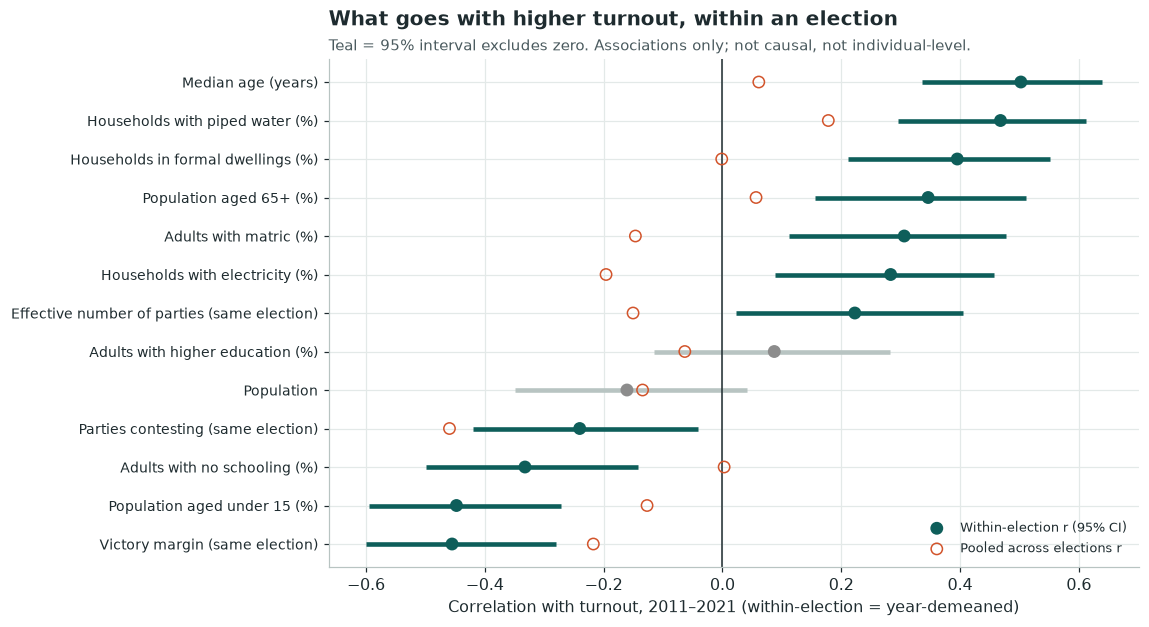

In [10]:
a = assoc.sort_values("WithinYear_r")
fig, ax = plt.subplots(figsize=(9.5, 6))
yy = np.arange(len(a))
sig = (a["WithinYear_lo"] > 0) | (a["WithinYear_hi"] < 0)
ax.hlines(yy, a["WithinYear_lo"], a["WithinYear_hi"], color=np.where(sig, C.TEAL, "#B8C4C2"), lw=3)
ax.scatter(a["WithinYear_r"], yy, color=np.where(sig, C.TEAL, C.GREY), s=55, zorder=3, label="Within-election r (95% CI)")
ax.scatter(a["Pooled_r"], yy, facecolor="none", edgecolor=C.ALOE, s=55, zorder=3, label="Pooled across elections r")
ax.axvline(0, color=C.INK, lw=1)
ax.set_yticks(yy); ax.set_yticklabels(a["Label"], fontsize=9)
ax.set_xlabel("Correlation with turnout, 2011–2021 (within-election = year-demeaned)"); ax.legend(loc="lower right", fontsize=8.5)
ax.set_title("What goes with higher turnout, within an election", pad=22)
subtitle(ax, "Teal = 95% interval excludes zero. Associations only; not causal, not individual-level.")
save(fig, "turnout_associations_forest", "phase3"); plt.show()

**Interpretation.**

- **Age structure.** Municipalities with a larger share of children under 15 have lower turnout (within-election r about −0.45), and older municipalities higher turnout. Census does not tell us the age of voters, so this is a statement about *places*, not about young people's behaviour.
- **Living conditions.** Piped water, formal housing, electricity and matric attainment all go with higher turnout. These indicators move together (the young, less-serviced east versus the older, better-serviced west in Notebook 02), so they are best read as one "development" dimension.
- **Competition.** Closer contests (smaller margins) and more effective parties go with higher turnout, consistent with the aggregate turnout literature (Geys, 2006). These are measured *in the same election*, so they describe co-occurrence only and are never used as predictors.
- **Party count** is negative, but that mainly reflects metros and large municipalities attracting many small parties.

## 5. How much do municipal characteristics add, once the election is accounted for?

A regression with **election fixed effects** removes the province-wide shock. The specification was fixed in advance with one variable per dimension (age structure: under-15 share; services: piped water; competition: margin), because the full set is highly collinear. Standard errors are clustered by municipality.

In [11]:
from src.analysis.associations import fixed_effects_regression, vif_table, year_only_r2
d = master[master["Year"] >= 2011]
spec = ["U15", "Water", "Margin_pts"]
r2_year = year_only_r2(master)
res, coefs = fixed_effects_regression(master, spec)
r2_table = pd.DataFrame({"Model": ["Election year only", "Election year + age, services, competition"],
                         "R2": [r2_year, res.rsquared], "n": [len(d), int(res.nobs)]})
display(r2_table.round(3))
display(coefs.round(3))
display(vif_table(d, ["U15", "Water", "Margin_pts", "Matric", "Elec"]).round(2))

,Model,R2,n
0,Election year only,0.51,99
1,"Election year + age, services, competition",0.63,99


,Variable,Coef_pts_per_SD,CI_low,CI_high,p_value
0,U15,-0.97,-3.02,1.07,0.35
1,Water,0.37,-1.93,2.67,0.75
2,Margin_pts,-1.05,-3.06,0.96,0.30


,Variable,VIF
0,U15,4.06
1,Water,7.70
2,Margin_pts,4.30
3,Matric,3.41
4,Elec,2.39


**Interpretation.** The election year alone explains about **51%** of the variation in municipal turnout across 2011–2021; adding the three municipal characteristics raises this to about **63%**. In the joint model the coefficients keep the expected signs (younger → lower, more serviced → higher, wider margin → lower) but none is individually distinguishable from zero: the dimensions overlap (variance inflation factors up to about 8) and there are only 33 municipalities. The honest conclusion is that **municipal context matters jointly**, but this data cannot attribute turnout differences to one characteristic rather than another.

## 6. Persistence: the bridge to prediction

,Transition,TargetYear,n,r_turnout,r_relative,MeanChange_pts,SD_change_pts
0,2000->2006,2006,32,0.32,0.32,0.86,5.21
1,2006->2011,2011,33,0.27,0.27,0.85,5.05
2,2011->2016,2016,33,0.83,0.83,-1.80,2.69
3,2016->2021,2021,33,0.77,0.77,-8.20,2.82


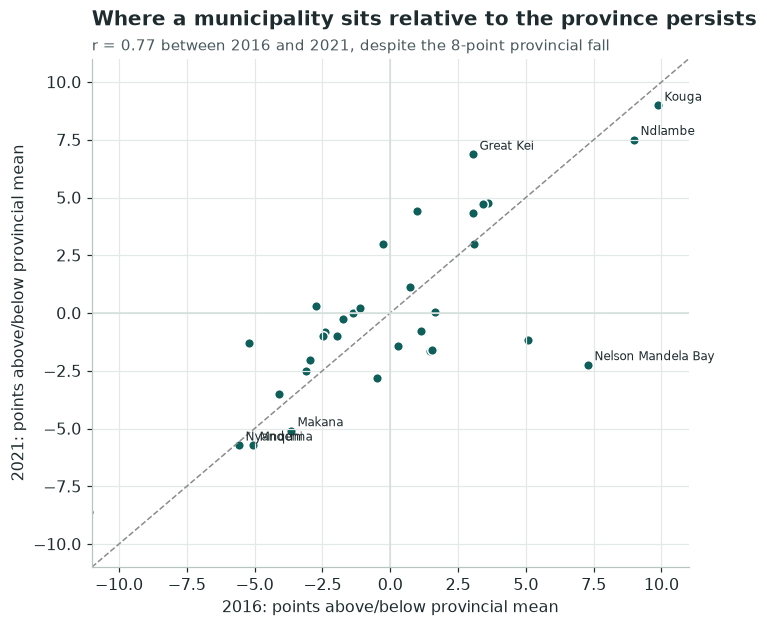

In [12]:
from src.analysis.associations import turnout_persistence
persist = turnout_persistence(master)
display(persist.round(3))

d = master[master["Year"] == 2021]
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(d["PreviousRelative_pts"], d["RelativeTurnout_pts"], color=C.TEAL, s=40, edgecolor="white")
for _, r in d.iterrows():
    if abs(r["RelativeTurnout_pts"]) > 5 or abs(r["PreviousRelative_pts"]) > 6:
        ax.annotate(r["Municipality"], (r["PreviousRelative_pts"], r["RelativeTurnout_pts"]), fontsize=8, xytext=(4, 3), textcoords="offset points")
lim = [-11, 11]; ax.plot(lim, lim, ls="--", color=C.GREY, lw=1)
ax.axhline(0, color="#D5DEDC", lw=1); ax.axvline(0, color="#D5DEDC", lw=1)
ax.set(xlim=lim, ylim=lim, xlabel="2016: points above/below provincial mean", ylabel="2021: points above/below provincial mean")
r = d["PreviousRelative_pts"].corr(d["RelativeTurnout_pts"])
ax.set_title("Where a municipality sits relative to the province persists", pad=22)
subtitle(ax, f"r = {r:.2f} between 2016 and 2021, despite the 8-point provincial fall")
save(fig, "relative_turnout_persistence", "phase3"); plt.show()

**Interpretation.** Since 2011 a municipality's position relative to the provincial average carries over strongly from one election to the next (r about 0.83 for 2011→2016 and 0.77 for 2016→2021). Earlier transitions were much noisier (r about 0.3), plausibly because municipal structures were still settling after 2000 and the 2006 cross-boundary changes. This is the key insight for Notebook 04: **the municipal pattern is predictable; the provincial level is not.**

## 7. Save outputs

In [13]:
out = C.DIRS["phase3"]
files = {"master_panel_2000_2021.csv": master,
         "provincial_summary_by_year.csv": summary,
         "municipality_turnout_change.csv": chg,
         "turnout_associations_2011_2021.csv": assoc,
         "turnout_fe_regression_2011_2021.csv": coefs,
         "turnout_regression_r2.csv": r2_table,
         "turnout_persistence.csv": persist,
         "phase3_quality_control.csv": qc}
for name, df in files.items():
    df.to_csv(out / name, index=False); print(f"Saved {name:44s} {len(df):4d} rows")

Saved master_panel_2000_2021.csv                    164 rows
Saved provincial_summary_by_year.csv                  5 rows
Saved municipality_turnout_change.csv                33 rows
Saved turnout_associations_2011_2021.csv             13 rows
Saved turnout_fe_regression_2011_2021.csv             3 rows
Saved turnout_regression_r2.csv                       2 rows
Saved turnout_persistence.csv                         4 rows
Saved phase3_quality_control.csv                      6 rows


## Answer to Component A

1. **Turnout differences between elections dwarf differences between municipalities.** The 2021 fall of about 8 points hit all 33 municipalities and explains why naive pooled analysis goes wrong.
2. **Within an election**, higher turnout is associated with older age structures, better household services and education, and closer, more fragmented contests.
3. These characteristics **overlap**, so their separate effects cannot be isolated with 33 municipalities; jointly they add about 12 points of explained variance beyond the election year.
4. **Relative turnout is persistent**, which makes municipal turnout forecastable *relative to the province*.

**Limitations.** Ecological associations only (Robinson, 1950); 2016/2021 demographics are interpolated; same-election competition measures are descriptive; 33 units limit statistical power.

## References

Citations were compiled by the team; verify page/URL details before final submission.

- Electoral Commission of South Africa (IEC). Municipal (Local Government) Election results, detailed downloads 2000, 2006, 2011, 2016, 2021. https://results.elections.org.za/home/downloads/me-results
- Statistics South Africa. Census 2011 and Census 2022 (https://census.statssa.gov.za). Note: the upstream tables behind data/processed/demographics/clean_census.csv are not recorded in the repository; see docs/DATA_SOURCES.md.
- Simpson, E.H. (1951). The interpretation of interaction in contingency tables. Journal of the Royal Statistical Society B, 13(2), 238-241.
- Robinson, W.S. (1950). Ecological correlations and the behavior of individuals. American Sociological Review, 15(3), 351-357.
- Geys, B. (2006). Explaining voter turnout: a review of aggregate-level research. Electoral Studies, 25(4), 637-663.
- Laakso, M. & Taagepera, R. (1979). 'Effective' number of parties: a measure with application to West Europe. Comparative Political Studies, 12(1), 3-27.
- Seabold, S. & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. Proc. 9th Python in Science Conf.

In [14]:
# Software used in this notebook (versions recorded for reproducibility)
import platform
from importlib.metadata import version, PackageNotFoundError
rows = [("python", platform.python_version())]
for pkg in ['pandas', 'numpy', 'matplotlib', 'scikit-learn', 'statsmodels', 'shapely', 'xlrd', 'nbformat']:
    try:
        rows.append((pkg, version(pkg)))
    except PackageNotFoundError:
        rows.append((pkg, "not installed"))
display(pd.DataFrame(rows, columns=["Package", "Version"]))

,Package,Version
0,python,3.13.15
1,pandas,3.0.6
2,numpy,2.5.3
3,matplotlib,3.11.2
4,scikit-learn,1.9.1
5,statsmodels,0.15.0
6,shapely,2.1.2
7,xlrd,2.0.2
8,nbformat,5.11.1
